<a href="https://colab.research.google.com/github/21040338-creator/Proyecto-Titanic-Machine-Learning1/blob/main/proyectou3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
                                        #Título del proyecto
# Proyecto Integrador: Análisis de Modelos de Clasificación en el Titanic

## Objetivo general

Analizar y comparar el desempeño de diferentes algoritmos de Machine Learning supervisado para predecir si un pasajero del Titanic sobrevivió o no, utilizando el dataset Titanic de Kaggle.

Los modelos a comparar son:

- KNN
- Regresión Logística
- Árbol de Decisión
- Random Forest
- SVM


In [6]:
                                       #  Importar librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")


In [7]:
                                # — Cargar los archivos
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
gender_submission = pd.read_csv("gender_submission.csv")


In [8]:
                            # — Después de subirlos, ejecuta
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
gender_submission = pd.read_csv("gender_submission.csv")


In [9]:
                                         #— Ver primeras filas
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
                                  #— Información general del dataset
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
                                      # — Estadísticas descriptivas

train.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
                                 #— Revisar valores nulos
train.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
                                        #Análisis exploratorio EDA

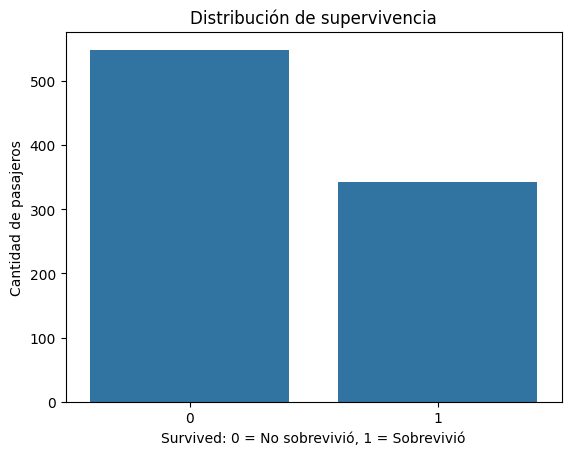

In [14]:
                                      #— Distribución de supervivencia

sns.countplot(data=train, x="Survived")
plt.title("Distribución de supervivencia")
plt.xlabel("Survived: 0 = No sobrevivió, 1 = Sobrevivió")
plt.ylabel("Cantidad de pasajeros")
plt.show()


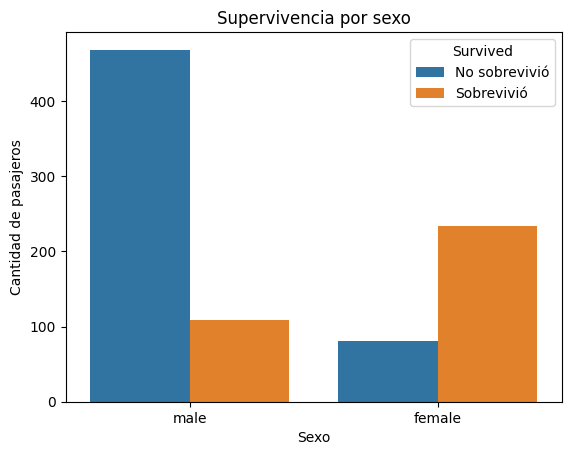

In [15]:
                                  #Supervivencia por sexo

sns.countplot(data=train, x="Sex", hue="Survived")
plt.title("Supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de pasajeros")
plt.legend(title="Survived", labels=["No sobrevivió", "Sobrevivió"])
plt.show()


In [16]:
                         # — Tasa de supervivencia por sexo

survival_by_sex = train.groupby("Sex")["Survived"].mean()
survival_by_sex


,Survived
Sex,
female,0.742038
male,0.188908


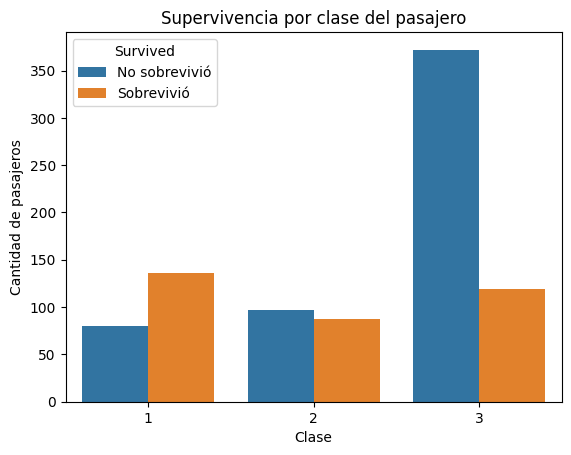

In [18]:
                                #— Supervivencia por clase
sns.countplot(data=train, x="Pclass", hue="Survived")
plt.title("Supervivencia por clase del pasajero")
plt.xlabel("Clase")
plt.ylabel("Cantidad de pasajeros")
plt.legend(title="Survived", labels=["No sobrevivió", "Sobrevivió"])
plt.show()


In [19]:
                            #— Tasa de supervivencia por clase

survival_by_class = train.groupby("Pclass")["Survived"].mean()
survival_by_class


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


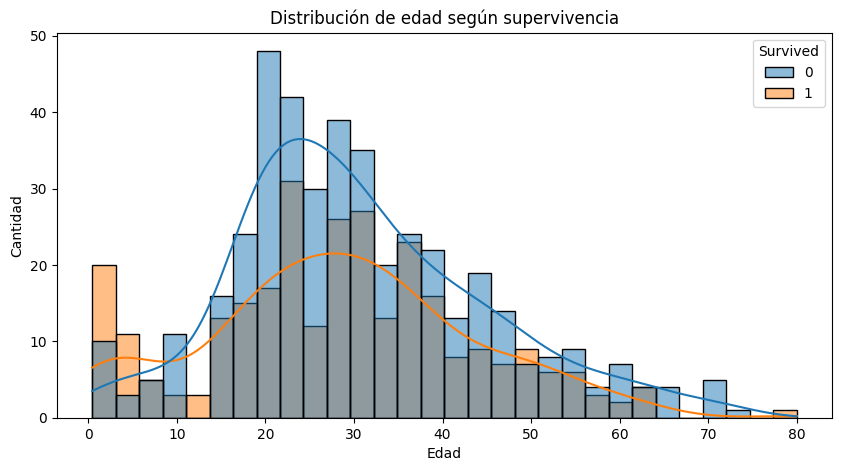

In [20]:
                                 # Supervivencia por edad

plt.figure(figsize=(10,5))
sns.histplot(data=train, x="Age", hue="Survived", kde=True, bins=30)
plt.title("Distribución de edad según supervivencia")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.show()


In [ ]:
#— Interpretación del EDA

## Interpretación del análisis exploratorio

A partir del análisis exploratorio se observan algunos patrones importantes:

- Las mujeres tuvieron una mayor tasa de supervivencia que los hombres.
- Los pasajeros de primera clase tuvieron mayor probabilidad de sobrevivir.
- La edad también parece influir, especialmente en algunos grupos de niños y adultos.
- Existen valores nulos en variables como Age, Cabin y Embarked.
- La variable Cabin tiene muchos datos faltantes, por lo que puede eliminarse para simplificar el análisis.


In [ ]:
                                              #Limpieza de datos

In [22]:
                                  # — Copiar dataset

df = train.copy()


In [23]:
                             #— Eliminar columnas no necesarias

df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])


In [24]:
                                  #Rellenar valores nulos

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


In [25]:
                            #— Confirmar que ya no hay nulos

df.isnull().sum()


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
                                         #Selección de variables


In [26]:
                                         #— Definir X e y

X = df.drop("Survived", axis=1)
y = df["Survived"]



In [27]:
X.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [28]:
                          #— Separar variables numéricas y categóricas
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]


In [29]:
                                             #— Preprocesamiento

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

preprocessor_no_scaled = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)


In [ ]:
#— Justificación del escalamiento


El escalamiento es importante en modelos como KNN y SVM porque ambos dependen de distancias entre puntos o márgenes de separación. Si una variable tiene valores mucho más grandes que otra, puede dominar el cálculo y afectar el rendimiento del modelo.

En cambio, los modelos basados en árboles, como Árbol de Decisión y Random Forest, no necesitan escalamiento porque toman decisiones mediante divisiones o reglas sobre las variables, no mediante distancias.


In [31]:
                               #División entrenamiento/prueba

           #— Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


In [32]:
                                  #Entrenamiento de modelos

  #— Crear modelos
models = {
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Regresión Logística": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Árbol de Decisión": Pipeline(steps=[
        ("preprocessor", preprocessor_no_scaled),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_no_scaled),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),

    "SVM": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", SVC(probability=True, random_state=42))
    ])
}


Modelo: KNN
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       165
           1       0.76      0.67      0.71       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.79      0.79      0.79       268



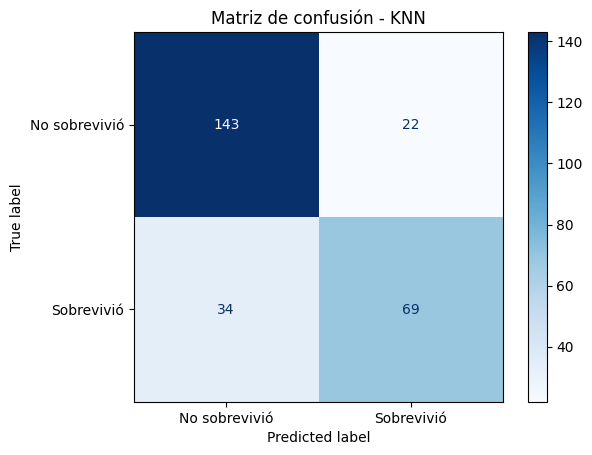

Modelo: Regresión Logística
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       165
           1       0.74      0.73      0.74       103

    accuracy                           0.80       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



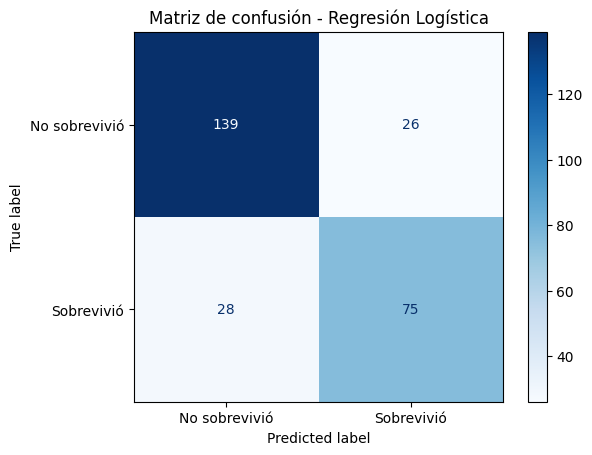

Modelo: Árbol de Decisión
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       165
           1       0.73      0.64      0.68       103

    accuracy                           0.77       268
   macro avg       0.76      0.74      0.75       268
weighted avg       0.77      0.77      0.77       268



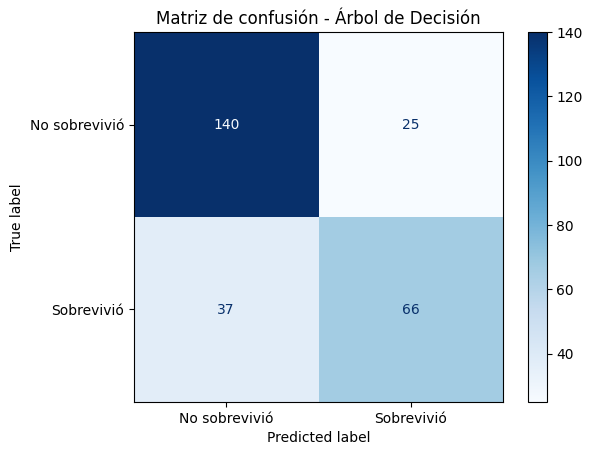

Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       165
           1       0.79      0.66      0.72       103

    accuracy                           0.80       268
   macro avg       0.80      0.78      0.78       268
weighted avg       0.80      0.80      0.80       268



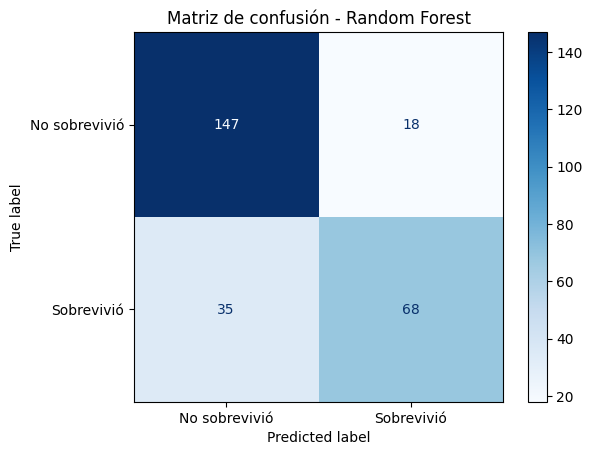

Modelo: SVM
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       165
           1       0.79      0.72      0.75       103

    accuracy                           0.82       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.82      0.82      0.82       268



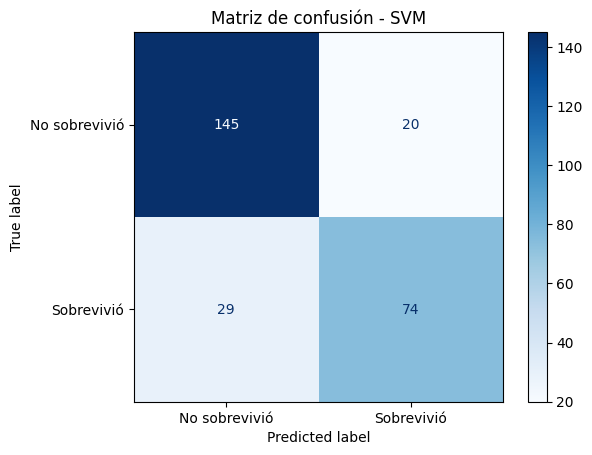

In [33]:
                                    #Entrenar y evaluar modelos

results = []

for name, model in models.items():
    print("="*60)
    print(f"Modelo: {name}")
    print("="*60)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model.named_steps["model"], "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No sobrevivió", "Sobrevivió"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {name}")
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    precision_0 = precision_score(y_test, y_pred, pos_label=0)
    recall_0 = recall_score(y_test, y_pred, pos_label=0)
    f1_0 = f1_score(y_test, y_pred, pos_label=0)

    precision_1 = precision_score(y_test, y_pred, pos_label=1)
    recall_1 = recall_score(y_test, y_pred, pos_label=1)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)

    results.append({
        "Modelo": name,
        "Accuracy": accuracy,
        "Precision No sobrevivió": precision_0,
        "Recall No sobrevivió": recall_0,
        "F1 No sobrevivió": f1_0,
        "Precision Sobrevivió": precision_1,
        "Recall Sobrevivió": recall_1,
        "F1 Sobrevivió": f1_1,
        "AUC": auc
    })


In [34]:
                                 #Tabla comparativa

                          #Crear tabla resumen
results_df = pd.DataFrame(results)
results_df


,Modelo,Accuracy,Precision No sobrevivió,Recall No sobrevivió,F1 No sobrevivió,Precision Sobrevivió,Recall Sobrevivió,F1 Sobrevivió,AUC
0,KNN,0.791045,0.807910,0.866667,0.836257,0.758242,0.669903,0.711340,0.830274
1,Regresión Logística,0.798507,0.832335,0.842424,0.837349,0.742574,0.728155,0.735294,0.849632
2,Árbol de Decisión,0.768657,0.790960,0.848485,0.818713,0.725275,0.640777,0.680412,0.746455
3,Random Forest,0.802239,0.807692,0.890909,0.847262,0.790698,0.660194,0.719577,0.846955
4,SVM,0.817164,0.833333,0.878788,0.855457,0.787234,0.718447,0.751269,0.839570


In [35]:
#— Ordenar por Accuracy

results_df.sort_values(by="Accuracy", ascending=False)



,Modelo,Accuracy,Precision No sobrevivió,Recall No sobrevivió,F1 No sobrevivió,Precision Sobrevivió,Recall Sobrevivió,F1 Sobrevivió,AUC
4,SVM,0.817164,0.833333,0.878788,0.855457,0.787234,0.718447,0.751269,0.839570
3,Random Forest,0.802239,0.807692,0.890909,0.847262,0.790698,0.660194,0.719577,0.846955
1,Regresión Logística,0.798507,0.832335,0.842424,0.837349,0.742574,0.728155,0.735294,0.849632
0,KNN,0.791045,0.807910,0.866667,0.836257,0.758242,0.669903,0.711340,0.830274
2,Árbol de Decisión,0.768657,0.790960,0.848485,0.818713,0.725275,0.640777,0.680412,0.746455


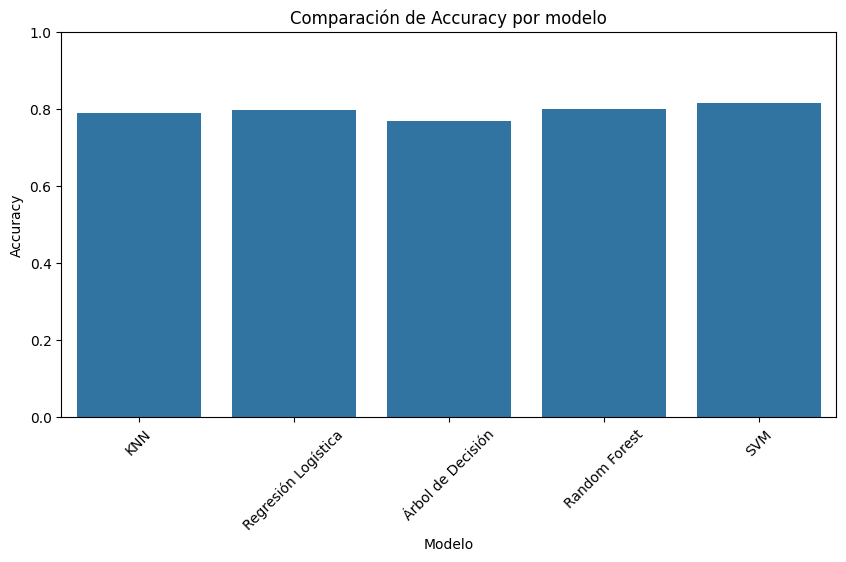

In [36]:
#— Gráfico comparativo de Accuracy
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Modelo", y="Accuracy")
plt.title("Comparación de Accuracy por modelo")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()


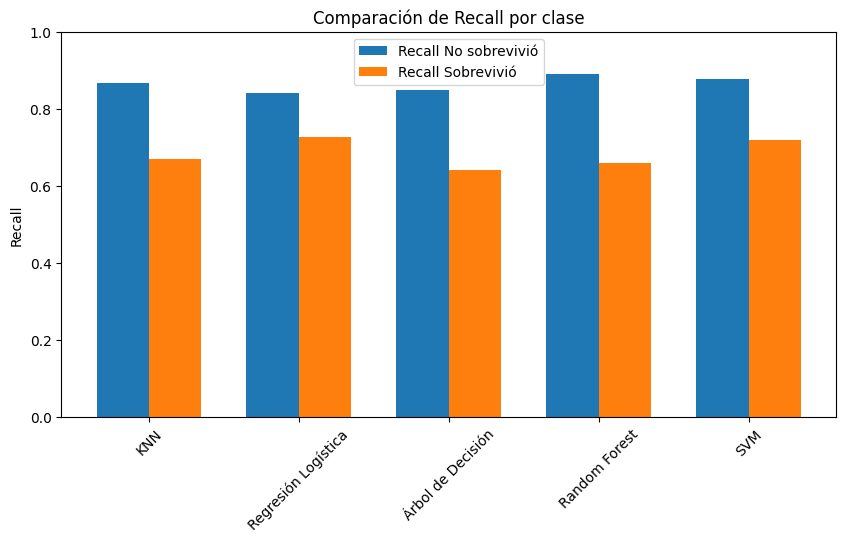

In [37]:
#— Gráfico comparativo de Recall
plt.figure(figsize=(10,5))

bar_width = 0.35
x = np.arange(len(results_df["Modelo"]))

plt.bar(x - bar_width/2, results_df["Recall No sobrevivió"], width=bar_width, label="Recall No sobrevivió")
plt.bar(x + bar_width/2, results_df["Recall Sobrevivió"], width=bar_width, label="Recall Sobrevivió")

plt.xticks(x, results_df["Modelo"], rotation=45)
plt.ylim(0, 1)
plt.title("Comparación de Recall por clase")
plt.ylabel("Recall")
plt.legend()
plt.show()


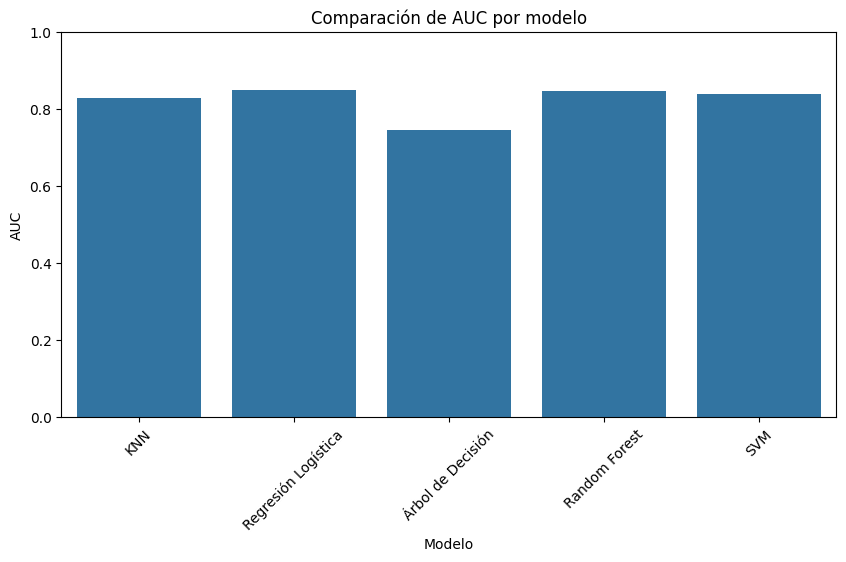

In [38]:
#— Gráfico comparativo de AUC
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Modelo", y="AUC")
plt.title("Comparación de AUC por modelo")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Interpretación individual de modelos

## KNN

KNN clasifica un nuevo dato observando los vecinos más cercanos dentro del conjunto de entrenamiento. Su predicción depende de la clase más común entre esos vecinos.

### Ventajas
- Es fácil de entender.
- Funciona bien en datasets pequeños.
- Puede capturar fronteras de decisión no lineales.

### Limitaciones
- Es sensible al escalamiento.
- Puede ser lento con datasets grandes.
- Su rendimiento depende del valor de K.

### Interpretación
En este proyecto, KNN puede detectar patrones de supervivencia basados en similitud entre pasajeros. Sin embargo, puede verse afectado si las variables no están correctamente escaladas.

### Recomendaciones
- Probar diferentes valores de K.
- Usar StandardScaler.
- Eliminar variables poco relevantes.


In [ ]:
## Regresión Logística

La Regresión Logística es un modelo lineal utilizado para clasificación binaria. Estima la probabilidad de que una observación pertenezca a una clase.

### Ventajas
- Es interpretable.
- Es rápida.
- Funciona bien como modelo base.

### Limitaciones
- Puede tener bajo rendimiento si la relación entre variables y objetivo no es lineal.
- Puede requerir escalamiento para mejorar estabilidad.

### Interpretación
Este modelo ayuda a entender qué variables influyen en la supervivencia. Variables como sexo, clase y tarifa suelen tener un efecto importante.

### Recomendaciones
- Revisar coeficientes del modelo.
- Usar variables relevantes.
- Comparar con modelos más complejos.


In [ ]:
## Árbol de Decisión

El Árbol de Decisión clasifica dividiendo los datos mediante reglas basadas en las variables. Por ejemplo, puede separar pasajeros según sexo, clase o edad.

### Ventajas
- Es fácil de interpretar.
- No requiere escalamiento.
- Puede capturar relaciones no lineales.

### Limitaciones
- Puede sobreajustarse.
- Es sensible a pequeños cambios en los datos.

### Interpretación
Este modelo puede identificar reglas claras, como mayor supervivencia en mujeres o pasajeros de primera clase.

### Recomendaciones
- Limitar la profundidad del árbol.
- Ajustar hiperparámetros.
- Compararlo con Random Forest.


In [ ]:
## Random Forest

Random Forest combina muchos árboles de decisión para mejorar la precisión y reducir el sobreajuste.

### Ventajas
- Suele tener buen rendimiento.
- Es robusto al ruido.
- Reduce el sobreajuste comparado con un solo árbol.

### Limitaciones
- Es menos interpretable que un árbol individual.
- Puede requerir más tiempo de entrenamiento.

### Interpretación
En este proyecto, Random Forest suele ser uno de los mejores modelos porque combina varias reglas de decisión y captura relaciones complejas.

### Recomendaciones
- Ajustar número de árboles.
- Revisar importancia de variables.
- Probar profundidad máxima.


In [ ]:
## SVM

SVM busca encontrar una frontera óptima que separe las clases. Puede trabajar con fronteras lineales o no lineales mediante kernels.

### Ventajas
- Es potente para problemas de clasificación.
- Funciona bien con datos de alta dimensión.
- Puede capturar fronteras complejas.

### Limitaciones
- Requiere escalamiento.
- Puede ser costoso computacionalmente.
- Sus parámetros deben ajustarse cuidadosamente.

### Interpretación
SVM puede tener buen rendimiento si los datos están escalados correctamente. En el caso Titanic, puede encontrar separaciones útiles entre sobrevivientes y no sobrevivientes.

### Recomendaciones
- Escalar variables.
- Probar diferentes kernels.
- Ajustar C y gamma.


In [39]:
                                        #Comparativo final

# Obtener mejor modelo

best_model = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]
best_model


,4
Modelo,SVM
Accuracy,0.817164
Precision No sobrevivió,0.833333
Recall No sobrevivió,0.878788
F1 No sobrevivió,0.855457
Precision Sobrevivió,0.787234
Recall Sobrevivió,0.718447
F1 Sobrevivió,0.751269
AUC,0.83957


In [40]:
#— Conclusión automática base

print(f"El modelo con mejor Accuracy fue {best_model['Modelo']} con un valor de {best_model['Accuracy']:.4f}.")
print(f"Su Recall para No sobrevivió fue {best_model['Recall No sobrevivió']:.4f}.")
print(f"Su Recall para Sobrevivió fue {best_model['Recall Sobrevivió']:.4f}.")
print(f"Su AUC fue {best_model['AUC']:.4f}.")


El modelo con mejor Accuracy fue SVM con un valor de 0.8172.
Su Recall para No sobrevivió fue 0.8788.
Su Recall para Sobrevivió fue 0.7184.
Su AUC fue 0.8396.


In [ ]:
## Análisis comparativo final

El modelo que mejor predijo la supervivencia fue el que obtuvo el mayor accuracy y un buen equilibrio entre el recall de ambas clases.

Es importante analizar no solo el accuracy, sino también el recall de la clase 0, correspondiente a los pasajeros que no sobrevivieron, y el recall de la clase 1, correspondiente a los pasajeros que sí sobrevivieron.

Un modelo equilibrado es preferible porque permite identificar correctamente tanto a sobrevivientes como a no sobrevivientes. En este caso, el mejor modelo puede considerarse aquel que mantenga buen desempeño general sin favorecer excesivamente una sola clase.


In [ ]:
## Recomendaciones técnicas por modelo

| Modelo | Recomendaciones / Escenarios ideales |
|---|---|
| KNN | Escalar variables; funciona bien en datasets pequeños y con fronteras suaves. |
| Regresión Logística | Ideal para interpretabilidad y relaciones lineales. |
| Árbol de Decisión | No necesita escalado; fácil de interpretar, pero puede sobreajustar. |
| Random Forest | Recomendado para datasets con varias variables; robusto al ruido y reduce sobreajuste. |
| SVM | Requiere escalado; útil en datos con fronteras complejas o alta dimensionalidad. |


In [ ]:
## Reflexión final

El modelo que funcionó mejor fue aquel que obtuvo el mejor equilibrio entre accuracy, recall, F1-score y AUC. En problemas de clasificación, no siempre basta con elegir el modelo con mayor accuracy, ya que también es importante revisar si el modelo identifica correctamente ambas clases.

Las variables que más influyen en la supervivencia son:

- Sexo
- Clase del pasajero
- Edad
- Tarifa pagada
- Familiares a bordo

Los patrones sociales observados muestran que las mujeres tuvieron mayor probabilidad de sobrevivir. También se observa que los pasajeros de primera clase tuvieron mejores posibilidades de supervivencia que los de segunda y tercera clase.

Este análisis permite entender cómo ciertos factores sociales y económicos influyeron en la supervivencia durante el desastre del Titanic. En un contexto real, este tipo de análisis podría ayudar a tomar decisiones basadas en datos, identificar grupos de riesgo y mejorar protocolos de seguridad.
